# What is Perceptron?

## Overview

A **Perceptron** is the simplest form of a neural network for binary classification. It combines inputs with weights, applies an activation function, and outputs 0 or 1. It forms the foundation of modern deep learning models.

**Key Characteristics:**
- Takes multiple inputs and assigns weights
- Computes weighted sum and applies a threshold
- Binary classification output (0 or 1)
- Building block for neural networks

---

## Core Components

### 1. **Inputs** $(x_1, x_2, ..., x_n)$
Feature variables that the perceptron uses to make decisions. For example, in an OR gate: $(x_1, x_2) \in \{0,1\}^2$

### 2. **Weights** $(w_1, w_2, ..., w_n)$
Learned parameters that determine the importance of each input. Larger weights = higher impact on predictions.

### 3. **Bias** $(b)$
Constant value added to shift the decision boundary. Allows classification even when all inputs are zero.

**Weights vs. Bias:**
- Weights: Control how much each input influences output
- Bias: Control when the perceptron activates (independent of input)

### 4. **Net Input (Weighted Sum)**
$$z = \sum_{i=1}^{n} w_i x_i + b$$
Represents total activation strength before the activation function.

### 5. **Activation Function (Step Function)**
$$\hat{y} = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases}$$
Converts numerical input into binary output (0 or 1).

---

## Neural Network Fundamentals

A neural network extends the perceptron across multiple layers:

### 1. **Input Layer**
$$x = (x_1, x_2, ..., x_n)$$
Passes raw feature values to the next layer without computation.

### 2. **Hidden Layers**
Multiple neurons that learn intermediate representations.

**Hidden Layer Computation:**
$$z^{(1)} = W^{(1)}x + b^{(1)}$$
$$a^{(1)} = \sigma(z^{(1)})$$

Where $W^{(1)}$ is the weight matrix, $b^{(1)}$ is the bias vector, and $\sigma$ is a non-linear activation (ReLU, Sigmoid, Tanh, etc.).

### 3. **Output Layer**
$$z^{(2)} = W^{(2)}a^{(1)} + b^{(2)}$$
$$\hat{y} = \sigma(z^{(2)})$$

Activation depends on task:
- **Sigmoid:** Binary classification
- **Softmax:** Multi-class classification
- **Linear:** Regression

**Key Difference:** Multiple layers + non-linear activations allow neural networks to model complex, non-linear decision boundaries. A single perceptron can only model straight lines.

---

## Perceptron Training Process

### Steps:

1. **Compute Weighted Sum**
   $$z = \sum_{i=1}^{n} w_i x_i + b$$

2. **Apply Activation Function**
   $$\hat{y} = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{otherwise} \end{cases}$$

3. **Calculate Error**
   $$\text{error} = y - \hat{y}$$

4. **Update Weights**
   $$w_i \leftarrow w_i + \eta(y - \hat{y})x_i$$

5. **Update Bias**
   $$b \leftarrow b + \eta(y - \hat{y})$$

6. **Repeat** across multiple epochs until convergence

7. **Final Model**
   $$\hat{y} = \text{step}(w^T x + b)$$

---

## Implementation

Let's implement the perceptron model:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_or = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

Y_or = np.array([0, 1, 1, 1,])


class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.errors_per_epoch = []

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        print("linear_output: ", linear_output)
        print("(linear_output >= 0, 1, 0): ", np.where(linear_output >= 0, 1, 0))
        return np.where(linear_output >= 0, 1, 0)
    
    def fit(self, X, Y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        print("X.shape: ", X.shape)
        print("self.weights: ", self.weights)

        for _ in range(self.epochs):
            errors = 0

            for xi, target in zip(X, Y):
                linear_output = np.dot(xi, self.weights) + self.bias
                Y_pred = 1 if linear_output >= 0 else 0
                update = self.lr * (target - Y_pred)
                self.weights += update * xi
                self.bias += update
                errors += int(update != 0)
            
            self.errors_per_epoch.append(errors)

# Train the Perceptron
perceptron_or = Perceptron(learning_rate=0.1, epochs=20)
perceptron_or.fit(X_or, Y_or)

print("\n")
print("Weights:", perceptron_or.weights)
print("Bias:", perceptron_or.bias)
print("Predictions:", perceptron_or.predict(X_or))

X.shape:  (4, 2)
self.weights:  [0. 0.]


Weights: [0.1 0.1]
Bias: -0.1
linear_output:  [-0.1  0.   0.   0.1]
(linear_output >= 0, 1, 0):  [0 1 1 1]
Predictions: [0 1 1 1]


### <br>Decision Boundary Plot

linear_output:  [-0.3        -0.29899666 -0.29799331 ...  0.29799331  0.29899666
  0.3       ]
(linear_output >= 0, 1, 0):  [0 0 0 ... 1 1 1]


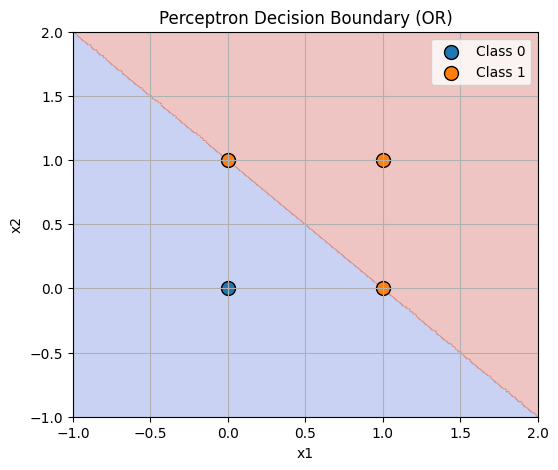

In [4]:
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    for label in np.unique(y):
        pts = X[y == label]
        plt.scatter(pts[:, 0], pts[:, 1],
                    s=100, edgecolor='black',
                    label=f"Class {label}")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_decision_boundary(X_or, Y_or, perceptron_or, "Perceptron Decision Boundary (OR)")

### <br>Plot Misclassifications per Epoch

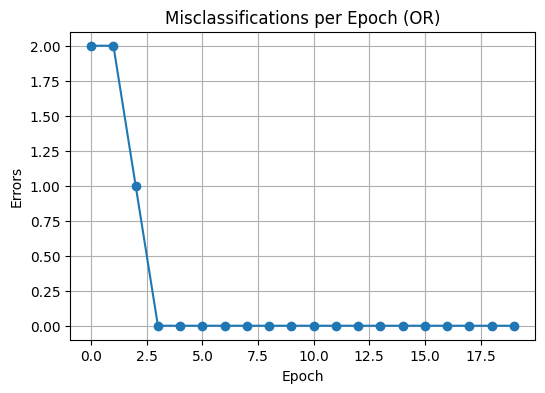

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(perceptron_or.errors_per_epoch, marker='o')
plt.title("Misclassifications per Epoch (OR)")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.grid(True)
plt.show()